# Phase C — Exploratory Data Analysis: Barcelona vs London

**Owner:** Member 2 (Mohammed)

Chains off Phase A (listing features) and Phase B (neighbourhood KPIs). Helpers in `src/eda.py`. Outputs go to `reports/`.

## Sections
1. Setup
2. Citywide overview (Q6 backbone)
3. Distributions — price, occupancy, host concentration
4. Top / bottom rankings (Q1, Q2, Q3, Q4 facts for the chatbot)
5. Geojson name alignment check (avoids silent map failures)
6. Choropleth maps
7. Time-series & emerging hotspots (Q5)
8. BCN vs LDN side-by-side comparison (Q6)
9. Save `eda_findings.md`

## 1. Setup

In [1]:
import sys
from pathlib import Path
import json

REPO_ROOT = Path.cwd().parent.resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_io import PROCESSED_DIR
from src import eda

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 100

REPORTS = REPO_ROOT / 'reports'
FIG_DIR = REPORTS / 'figures'
MAP_DIR = REPORTS / 'maps'
TBL_DIR = REPORTS / 'tables'
for d in (FIG_DIR, MAP_DIR, TBL_DIR):
    d.mkdir(parents=True, exist_ok=True)

CITY_COLOURS = {'barcelona': '#E63946', 'london': '#1D3557'}

bcn_feat = pd.read_csv(PROCESSED_DIR / 'barcelona' / 'barcelona_listings_features.csv')
ldn_feat = pd.read_csv(PROCESSED_DIR / 'london' / 'london_listings_features.csv')
features = pd.concat([bcn_feat, ldn_feat], ignore_index=True)
kpis = pd.read_csv(PROCESSED_DIR / 'neighbourhood_kpis.csv')

bcn_monthly = pd.read_csv(PROCESSED_DIR / 'barcelona' / 'barcelona_monthly_metrics_clean.csv', parse_dates=['month_date'])
bcn_monthly['city'] = 'barcelona'
ldn_monthly = pd.read_csv(PROCESSED_DIR / 'london' / 'london_monthly_metrics_clean.csv', parse_dates=['month_date'])
ldn_monthly['city'] = 'london'
monthly = pd.concat([bcn_monthly, ldn_monthly], ignore_index=True)

print(f'features: {features.shape}, kpis: {kpis.shape}, monthly: {monthly.shape}')

features: (12237, 50), kpis: (560, 27), monthly: (395643, 18)


## 2. Citywide overview (Q6 backbone)

In [2]:
overview = eda.citywide_overview(features)
overview.to_csv(TBL_DIR / 'citywide_overview.csv')
overview

,total_listings,unique_hosts,unique_subdivisions,active_listings,entire_homes,entire_home_share,median_nightly_price,median_occupancy_active,mean_occupancy_active,total_revenue,breach_90_total,reside_unregistered_total
city,,,,,,,,,,,,
barcelona,2594,1637,66,1655,1539,0.593,156.0,0.044,0.210,52159190.0,642,421
london,9643,7312,455,5967,6536,0.678,174.7,0.000,0.137,122631037.0,1485,2572


## 3. Distributions

### 3.1 Nightly price

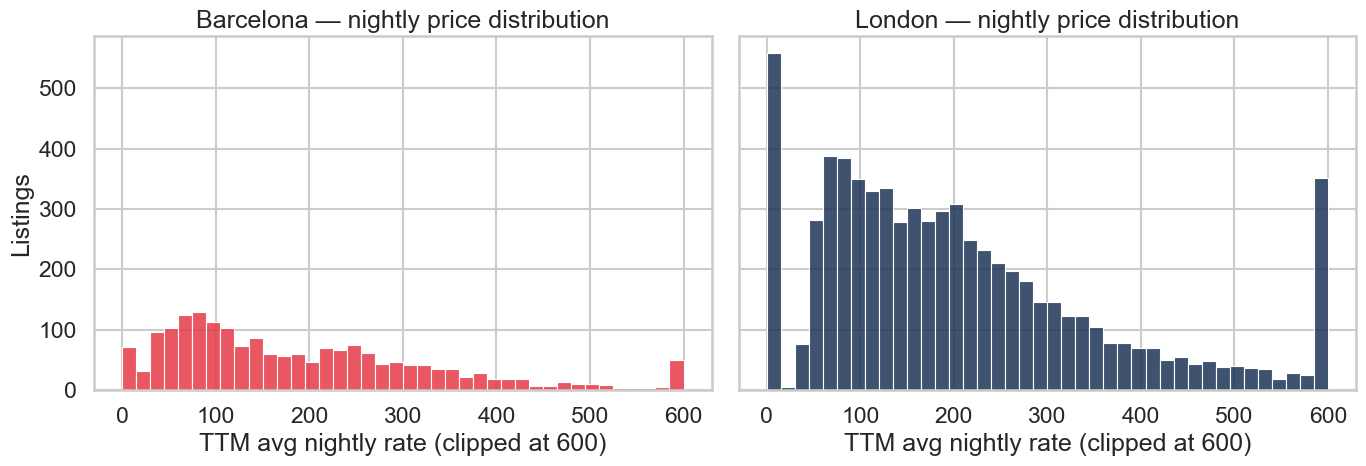

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, city in zip(axes, ['barcelona', 'london']):
    sub = features[(features['city']==city) & (features['ttm_avg_rate'].notna())]
    sns.histplot(sub['ttm_avg_rate'].clip(upper=600), bins=40, ax=ax,
                 color=CITY_COLOURS[city], alpha=0.85)
    ax.set_title(f'{city.title()} — nightly price distribution')
    ax.set_xlabel('TTM avg nightly rate (clipped at 600)')
    ax.set_ylabel('Listings')
fig.tight_layout()
fig.savefig(FIG_DIR / 'price_distribution.png', bbox_inches='tight')
plt.show()

### 3.2 Occupancy

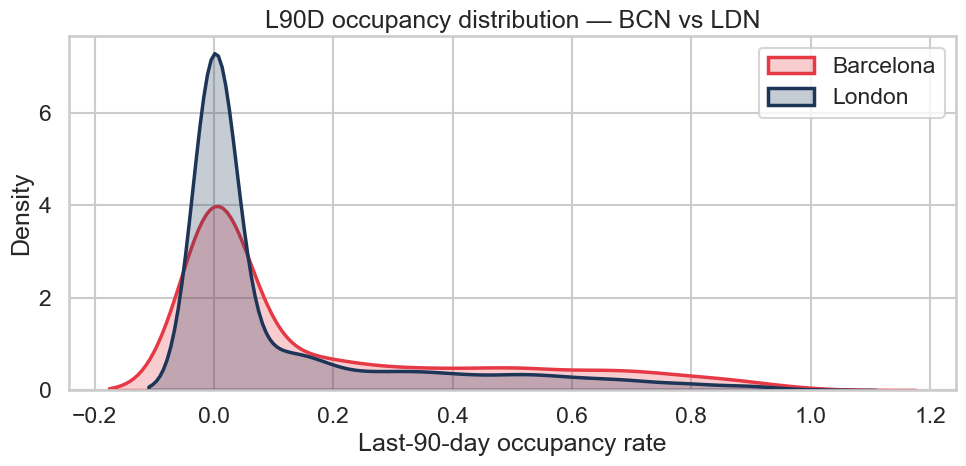

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
for city in ['barcelona', 'london']:
    sub = features[(features['city']==city) & (features['l90d_occupancy'].notna())]
    sns.kdeplot(sub['l90d_occupancy'], ax=ax, label=city.title(),
                color=CITY_COLOURS[city], linewidth=2.5, fill=True, alpha=0.25)
ax.set_title('L90D occupancy distribution — BCN vs LDN')
ax.set_xlabel('Last-90-day occupancy rate')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'occupancy_distribution.png', bbox_inches='tight')
plt.show()

### 3.3 Host concentration (Pareto-style)

In [5]:
host_summary = eda.host_concentration_summary(features)
host_summary.to_csv(TBL_DIR / 'host_concentration_summary.csv', index=False)
host_summary

,city,top_pct_hosts,n_hosts,revenue_share,listings_share
0,barcelona,0.01,16,0.2696,0.1218
1,barcelona,0.05,81,0.5469,0.2583
2,barcelona,0.10,163,0.7003,0.3620
3,barcelona,0.20,327,0.8830,0.4884
4,london,0.01,73,0.2077,0.0912
5,london,0.05,365,0.4886,0.2070
6,london,0.10,731,0.6675,0.2886
7,london,0.20,1462,0.8636,0.3933


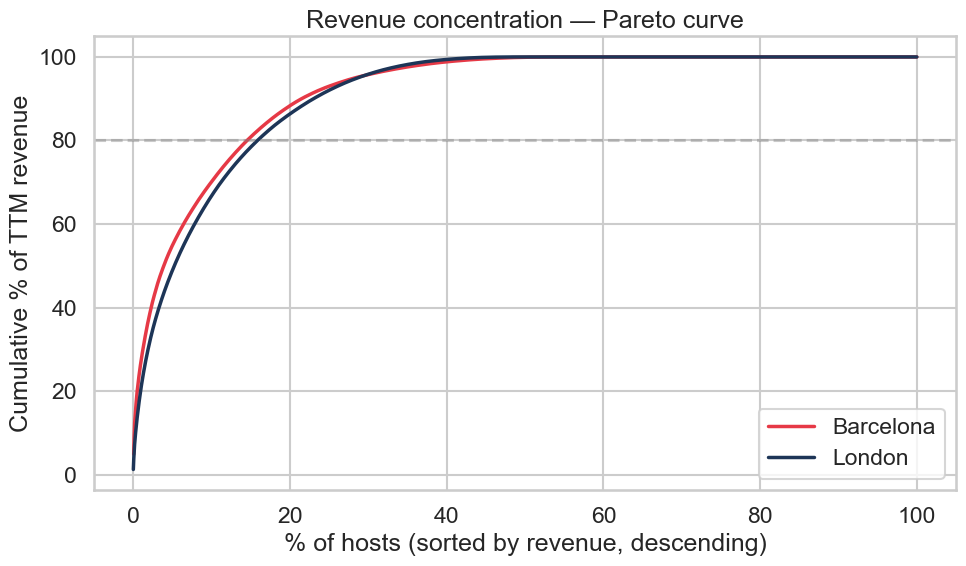

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
for city in ['barcelona', 'london']:
    host_rev = (
        features[features['city']==city]
        .groupby('host_id')['ttm_revenue'].sum().sort_values(ascending=False)
    )
    cum_share = host_rev.cumsum() / host_rev.sum()
    host_pct = (np.arange(len(host_rev)) + 1) / len(host_rev) * 100
    ax.plot(host_pct, cum_share * 100, label=city.title(),
            color=CITY_COLOURS[city], linewidth=2.5)
ax.set_xlabel('% of hosts (sorted by revenue, descending)')
ax.set_ylabel('Cumulative % of TTM revenue')
ax.set_title('Revenue concentration — Pareto curve')
ax.legend()
ax.axhline(80, linestyle='--', alpha=0.4, color='grey')
fig.tight_layout()
fig.savefig(FIG_DIR / 'host_pareto.png', bbox_inches='tight')
plt.show()

## 4. Top / bottom rankings (chatbot facts)

In [7]:
ranking_cfg = [
    ('str_density',         'Top 10 by STR density',          None),
    ('entire_home_share',   'Top 10 by entire-home share',    30),
    ('commercial_host_share', 'Top 10 by commercial host share', 30),
    ('breach_count_90',     'Top 10 by 90-night breach count', None),
    ('breach_rate_90',      'Top 10 by 90-night breach rate',  30),
    ('median_nightly_price','Top 10 by median nightly price',  30),
]
rankings = {}
for metric, title, min_d in ranking_cfg:
    for city in ['barcelona', 'london']:
        df = eda.top_n_by(kpis, metric, n=10, city=city, min_density=min_d)
        rankings[(city, metric)] = df
        df.to_csv(TBL_DIR / f'top10_{city}_{metric}.csv', index=False)
        print(f'\n{title} — {city.upper()}')
        print(df.to_string(index=False))


Top 10 by STR density — BARCELONA
     city                               geo_key  str_density
barcelona                la Dreta de l'Eixample          295
barcelona                              el Raval          203
barcelona Sant Pere, Santa Caterina i la Ribera          163
barcelona                        Gothic Quarter          160
barcelona       l'Antiga Esquerra de l'Eixample          148
barcelona                    la Sagrada Família          144
barcelona                          el Poble-sec          118
barcelona        la Nova Esquerra de l'Eixample          114
barcelona                     la Vila de Gràcia          104
barcelona                           Sant Antoni           79

Top 10 by STR density — LONDON
  city                  geo_key  str_density
london              Whitechapel          242
london         Westbourne Green          210
london               Marylebone          178
london             Earl's Court          168
london               Paddington      


Top 10 by 90-night breach count — BARCELONA
     city                               geo_key  str_density  breach_count_90
barcelona                la Dreta de l'Eixample          295               95
barcelona                    la Sagrada Família          144               53
barcelona                          el Poble-sec          118               46
barcelona       l'Antiga Esquerra de l'Eixample          148               43
barcelona                     la Vila de Gràcia          104               34
barcelona Sant Pere, Santa Caterina i la Ribera          163               31
barcelona        la Nova Esquerra de l'Eixample          114               31
barcelona                              el Raval          203               28
barcelona                           Sant Antoni           79               26
barcelona                           el Poblenou           59               21

Top 10 by 90-night breach count — LONDON
  city          geo_key  str_density  breach_count_90
l

## 5. Geojson name alignment check

Catch silent choropleth failures before they happen.

In [8]:
bcn_gdf = eda.load_geojson('barcelona')
ldn_gdf = eda.load_geojson('london')

bcn_kpi_keys = kpis.loc[kpis['city']=='barcelona', 'geo_key'].replace(eda.BCN_NAME_MAP)
bcn_align = eda.check_name_alignment(
    bcn_gdf[eda.GEOJSON_NAME_FIELD],
    bcn_kpi_keys,
)
print('BCN alignment:')
print(f'  geojson features : {bcn_align["geo_features"]}')
print(f'  kpi geo_keys     : {bcn_align["kpi_geo_keys"]}')
print(f'  matched          : {bcn_align["matched"]} ({bcn_align["match_rate"]*100:.1f}% of geojson)')
if bcn_align['only_in_geojson']:
    print(f'  only in geojson  : {bcn_align["only_in_geojson"][:10]}')
if bcn_align['only_in_kpis']:
    print(f'  only in kpis     : {bcn_align["only_in_kpis"][:10]}')

ldn_borough_kpis = eda.aggregate_to_london_boroughs(features)
ldn_align = eda.check_name_alignment(
    ldn_gdf[eda.GEOJSON_NAME_FIELD],
    ldn_borough_kpis['borough']
)
print('\nLDN alignment (borough-level):')
print(f'  geojson features : {ldn_align["geo_features"]}')
print(f'  kpi geo_keys     : {ldn_align["kpi_geo_keys"]}')
print(f'  matched          : {ldn_align["matched"]} ({ldn_align["match_rate"]*100:.1f}% of geojson)')
if ldn_align['only_in_geojson']:
    print(f'  only in geojson  : {ldn_align["only_in_geojson"]}')
if ldn_align['only_in_kpis']:
    print(f'  only in kpis     : {ldn_align["only_in_kpis"]}')

ldn_borough_kpis.to_csv(PROCESSED_DIR / 'london_borough_kpis.csv', index=False)

BCN alignment:
  geojson features : 73
  kpi geo_keys     : 66
  matched          : 65 (89.0% of geojson)
  only in geojson  : ['Baró de Viver', 'Can Peguera', 'Canyelles', 'Ciutat Meridiana', 'Sant Genís dels Agudells', 'Vallbona', 'el Bon Pastor', 'la Trinitat Nova']
  only in kpis     : ['Superilla Sant Antoni']



LDN alignment (borough-level):
  geojson features : 33
  kpi geo_keys     : 32
  matched          : 32 (97.0% of geojson)
  only in geojson  : ['City of London']


## 6. Choropleth maps

Interactive HTML via folium — open the files in `reports/maps/` in any browser.
Bonus: matplotlib choropleths via geopandas for static deck slides.

In [9]:
import folium

def folium_choropleth(gdf, data_df, key_field_geo, key_field_data, value_col,
                      city_centre, zoom, title):
    m = folium.Map(location=city_centre, zoom_start=zoom, tiles='cartodbpositron')
    folium.Choropleth(
        geo_data=gdf.__geo_interface__,
        data=data_df,
        columns=[key_field_data, value_col],
        key_on=f'feature.properties.{key_field_geo}',
        fill_color='YlOrRd',
        fill_opacity=0.75,
        line_opacity=0.4,
        legend_name=title,
    ).add_to(m)
    return m

bcn_kpis = kpis[kpis['city']=='barcelona'].copy()
bcn_kpis['geo_key'] = bcn_kpis['geo_key'].replace(eda.BCN_NAME_MAP)
for metric, label in [('str_density', 'STR density'),
                       ('entire_home_share', 'Entire-home share'),
                       ('breach_rate_90', '90-night breach rate'),
                       ('median_nightly_price', 'Median nightly price (EUR)')]:
    m = folium_choropleth(bcn_gdf, bcn_kpis, 'neighbourhood', 'geo_key', metric,
                          city_centre=[41.39, 2.16], zoom=12, title=f'BCN — {label}')
    out = MAP_DIR / f'bcn_{metric}.html'
    m.save(str(out))
    print(f'Saved {out.name}')

for metric, label in [('str_density', 'STR density'),
                       ('entire_home_share', 'Entire-home share'),
                       ('breach_rate_90', '90-night breach rate'),
                       ('median_nightly_price', 'Median nightly price (GBP)')]:
    m = folium_choropleth(ldn_gdf, ldn_borough_kpis, 'neighbourhood', 'borough', metric,
                          city_centre=[51.51, -0.12], zoom=10, title=f'LDN — {label}')
    out = MAP_DIR / f'ldn_{metric}.html'
    m.save(str(out))
    print(f'Saved {out.name}')

Saved bcn_str_density.html


Saved bcn_entire_home_share.html


Saved bcn_breach_rate_90.html


Saved bcn_median_nightly_price.html


Saved ldn_str_density.html


Saved ldn_entire_home_share.html


Saved ldn_breach_rate_90.html


Saved ldn_median_nightly_price.html


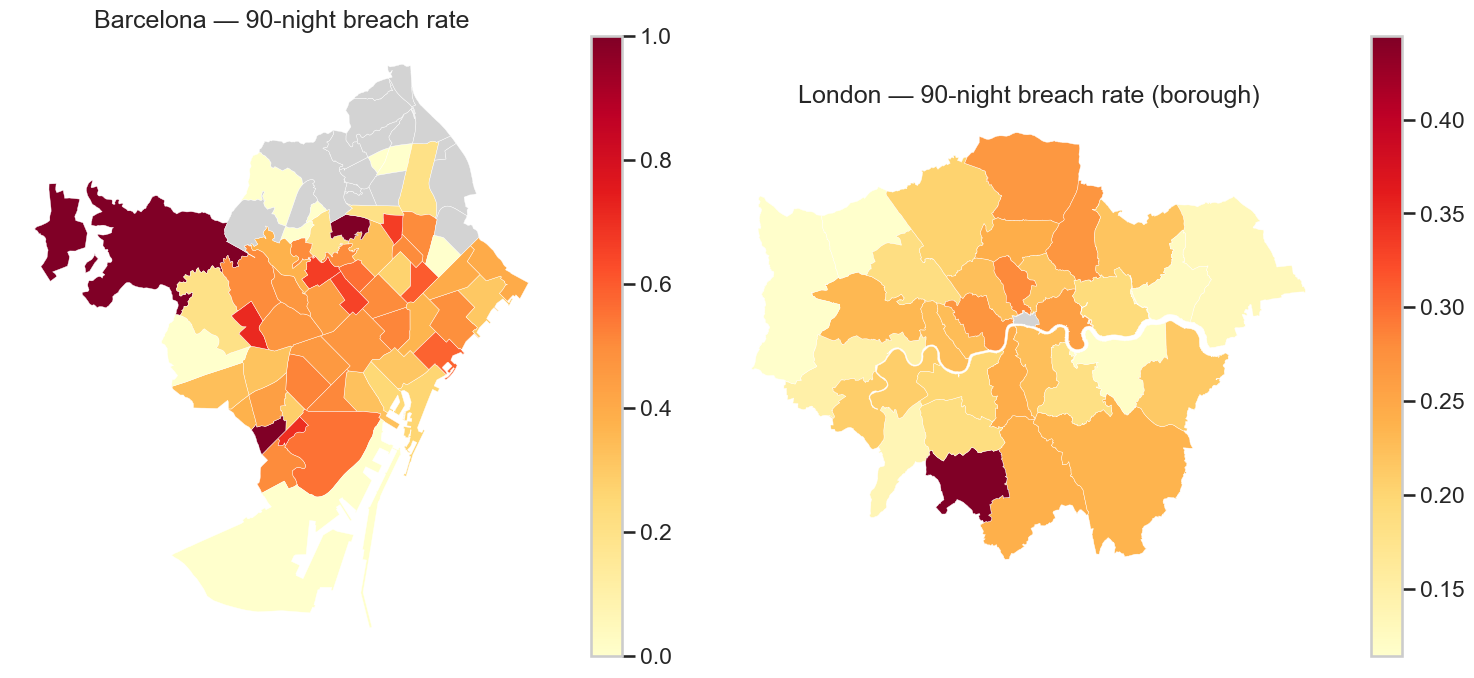

In [10]:
# Static PNG choropleths for the slide deck (matplotlib via geopandas)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

bcn_merged = bcn_gdf.merge(bcn_kpis, left_on='neighbourhood', right_on='geo_key', how='left')
bcn_merged.plot(column='breach_rate_90', cmap='YlOrRd', legend=True, ax=axes[0],
                edgecolor='white', linewidth=0.3,
                missing_kwds={'color': 'lightgrey'})
axes[0].set_title('Barcelona — 90-night breach rate')
axes[0].axis('off')

ldn_merged = ldn_gdf.merge(ldn_borough_kpis, left_on='neighbourhood', right_on='borough', how='left')
ldn_merged.plot(column='breach_rate_90', cmap='YlOrRd', legend=True, ax=axes[1],
                edgecolor='white', linewidth=0.3,
                missing_kwds={'color': 'lightgrey'})
axes[1].set_title('London — 90-night breach rate (borough)')
axes[1].axis('off')

fig.tight_layout()
fig.savefig(FIG_DIR / 'breach_rate_90_choropleth.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Time-series & emerging hotspots (Q5)

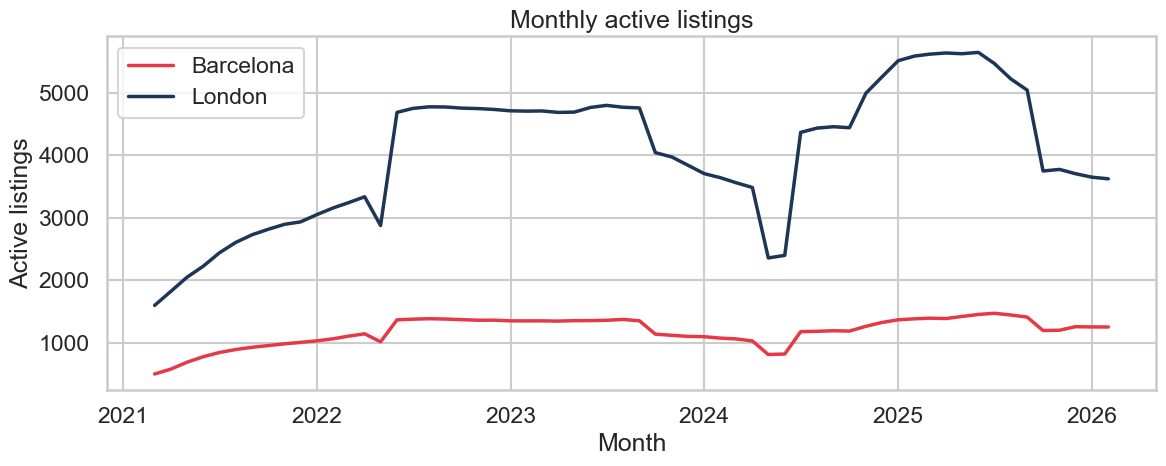

In [11]:
# Citywide monthly active listings
monthly_city = (
    monthly.groupby(['city', 'month_date'])['active'].sum().reset_index()
)
fig, ax = plt.subplots(figsize=(12, 5))
for city in ['barcelona', 'london']:
    sub = monthly_city[monthly_city['city']==city]
    ax.plot(sub['month_date'], sub['active'], label=city.title(),
            color=CITY_COLOURS[city], linewidth=2.5)
ax.set_title('Monthly active listings')
ax.set_xlabel('Month')
ax.set_ylabel('Active listings')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'active_listings_timeseries.png', bbox_inches='tight')
plt.show()

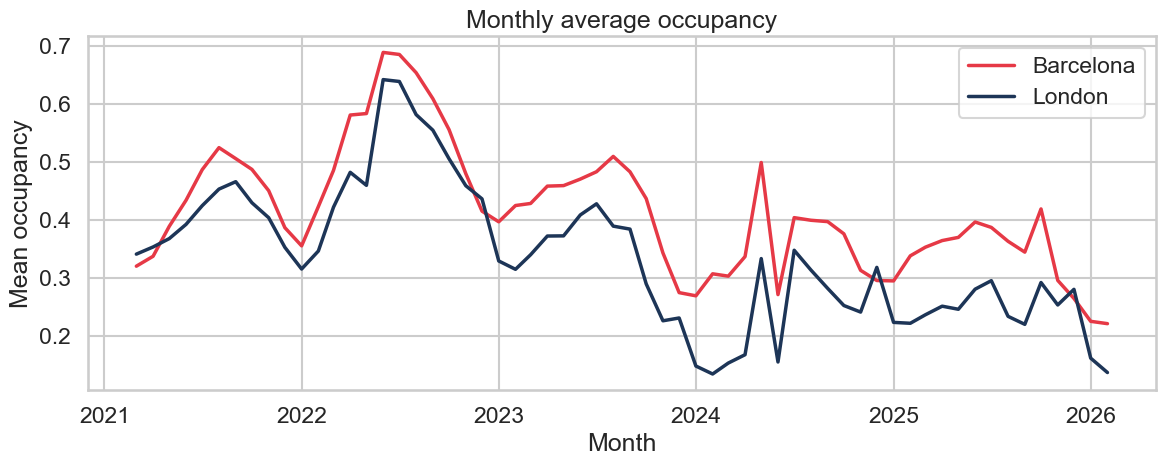

In [12]:
# Citywide monthly average occupancy
monthly_occ = (
    monthly.groupby(['city', 'month_date'])['occupancy'].mean().reset_index()
)
fig, ax = plt.subplots(figsize=(12, 5))
for city in ['barcelona', 'london']:
    sub = monthly_occ[monthly_occ['city']==city]
    ax.plot(sub['month_date'], sub['occupancy'], label=city.title(),
            color=CITY_COLOURS[city], linewidth=2.5)
ax.set_title('Monthly average occupancy')
ax.set_xlabel('Month')
ax.set_ylabel('Mean occupancy')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'occupancy_timeseries.png', bbox_inches='tight')
plt.show()

In [13]:
# Emerging hotspots — recent 6 months vs prior 6 months
hotspots = eda.emerging_hotspots(features, monthly, recent_months=6, prior_months=6, top_n=15)
hotspots.to_csv(TBL_DIR / 'emerging_hotspots.csv', index=False)
print('Top emerging hotspots (recent vs prior, top 15):')
print(hotspots.to_string(index=False))

Top emerging hotspots (recent vs prior, top 15):
     city               geo_key  recent_active  recent_revenue  prior_active  prior_revenue  active_growth_pct  revenue_growth_pct
barcelona              Can Baró       6.000000     8778.333333      5.000000   14625.000000              20.00              -39.98
   london             Greenford       5.666667     3695.166667      5.000000    4442.000000              13.33              -16.81
   london            Abbey Wood       6.500000     4787.500000      5.833333    5040.000000              11.43               -5.01
   london            Gants Hill       5.500000     7942.500000      5.000000   13511.666667              10.00              -41.22
   london           North Sheen      10.000000     8711.833333      9.833333   19660.000000               1.69              -55.69
   london            Earlsfield      13.666667    24511.666667     13.500000   31707.833333               1.23              -22.70
barcelona la Font de la Guatlla   

## 8. BCN vs LDN side-by-side comparison (Q6)

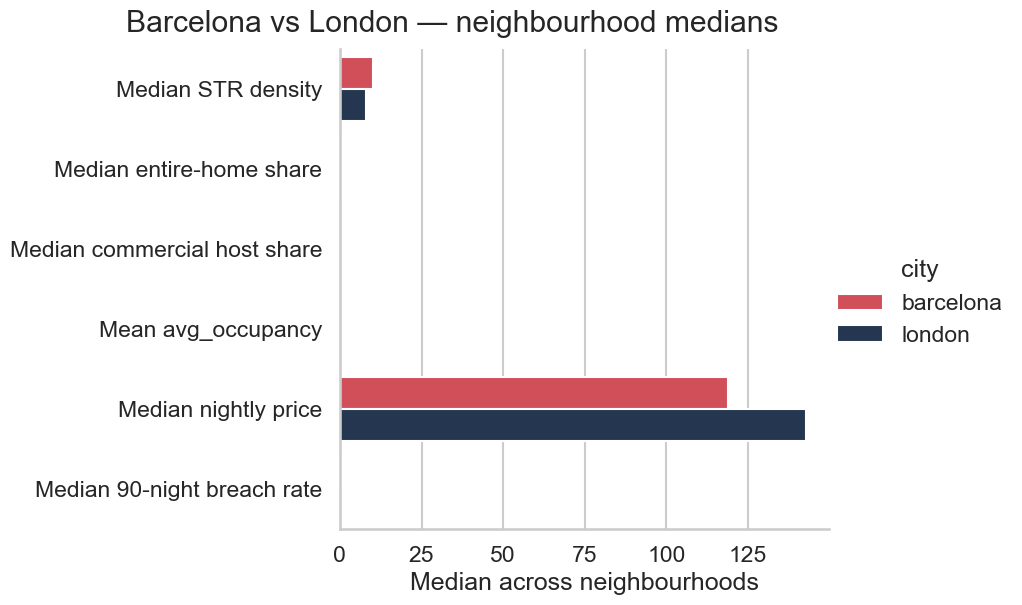

In [14]:
summary_metrics = {
    'str_density': 'Median STR density',
    'entire_home_share': 'Median entire-home share',
    'commercial_host_share': 'Median commercial host share',
    'avg_occupancy': 'Mean avg_occupancy',
    'median_nightly_price': 'Median nightly price',
    'breach_rate_90': 'Median 90-night breach rate',
}
rows = []
for metric, label in summary_metrics.items():
    for city in ['barcelona', 'london']:
        rows.append({
            'metric': label,
            'city': city,
            'value': kpis[kpis['city']==city][metric].median(),
        })
comp = pd.DataFrame(rows)
comp.to_csv(TBL_DIR / 'bcn_vs_ldn_comparison.csv', index=False)

g = sns.catplot(
    data=comp, kind='bar', x='value', y='metric', hue='city',
    palette=CITY_COLOURS, height=6, aspect=1.6,
)
g.set_axis_labels('Median across neighbourhoods', '')
g.fig.suptitle('Barcelona vs London — neighbourhood medians', y=1.02)
g.savefig(FIG_DIR / 'bcn_vs_ldn_medians.png', bbox_inches='tight')
plt.show()

## 9. Save `eda_findings.md` (narrative for Member 4)

In [15]:
lines = []
lines.append('# EDA Findings — Urban Rental Intelligence Copilot')
lines.append('')
lines.append('Auto-generated narrative for Member 4 to lift into the chatbot system prompt.')
lines.append('')
lines.append('## Citywide overview')
lines.append('')
lines.append(overview.to_markdown())
lines.append('')
lines.append('## Headline rankings')
lines.append('')
for (city, metric), df in rankings.items():
    if metric in ('breach_count_90', 'str_density'):
        lines.append(f'### {city.title()} — top 10 by `{metric}`')
        lines.append('')
        lines.append(df.to_markdown(index=False))
        lines.append('')
lines.append('## Emerging hotspots (recent 6 months vs prior 6 months)')
lines.append('')
lines.append(hotspots.to_markdown(index=False))
lines.append('')
lines.append('## Cross-city comparison medians')
lines.append('')
lines.append(comp.to_markdown(index=False))
lines.append('')
lines.append('## Caveats to surface in the chatbot')
lines.append('')
lines.append('- AirDNA is a sample (~14% of BCN, ~10% of LDN STR universe). Numbers are directional, not market-wide totals.')
lines.append('- Association, not causation — high STR density correlates with rent pressure but does not prove causation.')
lines.append('- `professional_management` was null in ~54% of LDN raw — share computed only over reported cases.')
lines.append('- Subdivision coverage gap: 9% BCN / 12% LDN listings have no subdivision; LDN choropleths roll up to borough.')
lines.append('- Time coverage: March 2021 – February 2026.')
out_path = REPORTS / 'eda_findings.md'
out_path.write_text('\n'.join(lines), encoding='utf-8')
print(f'Saved -> {out_path}')

Saved -> C:\Users\moham\Desktop\Term 3\Capstone\Repo\KPMG_Airbnb_Capstone\reports\eda_findings.md


## Handover to Member 3

- `data/processed/neighbourhood_kpis.csv` is the analytical backbone.
- `data/processed/london_borough_kpis.csv` is the borough-level LDN view (use for borough choropleths and rollups).
- All figures, maps, tables and findings live in `reports/`.
- Geojson alignment confirmed: BCN at subdivision level, LDN at borough level — note any 'only in geojson' subdivisions are uninhabited or missing in the AirDNA sample.